# Tokenizer Metric Figures

In [33]:
# Relative to root directory
RESULTS_NAME = "results/olmo_200k_1e8.jsonl"

## 0. Initial Setup

In [34]:
from pathlib import Path

import pandas as pd
import seaborn as sns

sns.set_theme()

## 1. Load results file into dataframe

In [35]:
# Notebook lives in notebooks/
RESULTS_PATH = Path().resolve().parent / RESULTS_NAME
df = (
    pd.read_json(RESULTS_PATH, lines=True)
    .sort_values(["t", "train_chars"])
    .reset_index(drop=True)
)
# Treat t as a discrete (ordered) category so seaborn enumerates every t value
# in the legend, rather than mapping integer t to a continuous colorbar that
# only labels ~6 round-number ticks.
df["t"] = pd.Categorical(df["t"], ordered=True)
df.head()

,cell,t,train_chars,test_chars,vocab_size,n_tokens,compression_ratio,H_1,H_2,H_3,H_4,H_5,eta,eta_2,cross_boundary_frac
0,t0_n1e3,0,1000,100000000,200000,57551133,1.749107,6.490669,4.999870,3.903565,3.088598,2.406693,0.368586,0.326825,0.174287
1,t0_n1e4,0,10000,100000000,200000,42449763,2.371347,8.671004,6.149929,4.397311,2.850311,1.611238,0.492401,0.435532,0.297377
2,t0_n1e5,0,100000,100000000,200000,29933349,3.362908,10.702827,7.245463,4.190295,1.676240,0.588071,0.607782,0.529896,0.400810
3,t0_n1e6,0,1000000,100000000,200000,21297028,4.726627,12.980096,7.942096,2.603029,0.517642,0.134429,0.737102,0.616685,0.518885
4,t0_n1e7,0,10000000,100000000,200000,16776142,6.000373,14.666069,7.674949,1.290997,0.205674,0.061621,0.832843,0.664048,0.618911


## 2. Figure 2: Compression Ratio vs Training Size

Reproduces Fig. 2 of Erdogan et al. (2026) for English C4 at vocab size 16,000. One line per SuperBPE transition point $t$. Higher = more compressive (fewer tokens per byte).

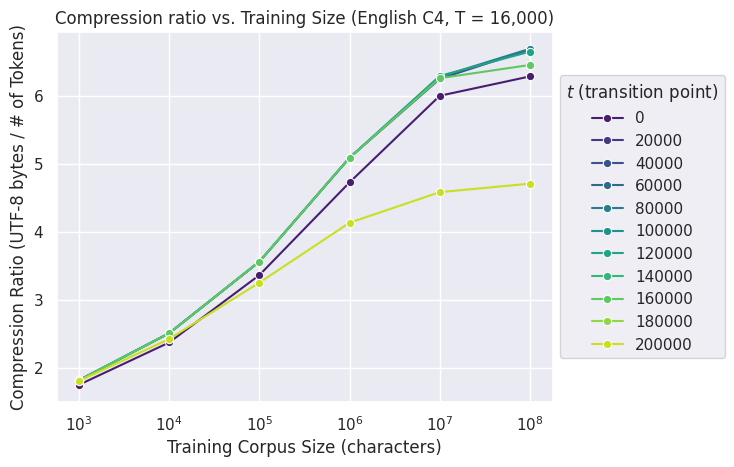

In [36]:
compression_fig = sns.lineplot(
    data=df[df["t"].isin([0, 40000, 80000, 120000, 160000, 200000])],
    # data=df,
    x="train_chars",
    y="compression_ratio",
    hue="t",
    marker="o",
    palette="viridis",
)

compression_fig.set(
    xscale="log",
    xlabel="Training Corpus Size (characters)",
    ylabel="Compression Ratio (UTF-8 bytes / # of Tokens)",
    title="Compression ratio vs. Training Size (English C4, T = 16,000)",
)
sns.move_legend(
    compression_fig,
    "center left",
    bbox_to_anchor=(1, 0.5),
    title=r"$t$ (transition point)",
)

## 3. Figure 4: k-gram Entropy vs Training Size

Reproduces Fig. 4 of Erdogan et al. (2026)

### Pre-computation and data transformation
Note that Fig. 4b converts $H_k$ (bits/token) to per-character entropy rate (bits/char):
$$ \text{entropy rate} = H_k \cdot \frac{\text{num tokens in test stream}}{\text{num chars in test stream}} $$

In [37]:
# 4a
# Melt H_1..H_5 into long form so we can facet with seaborn.
entropy_long = df.melt(
    id_vars=["t", "train_chars"],
    value_vars=[f"H_{k}" for k in range(1, 6)],
    var_name="k",
    value_name="entropy",
)
entropy_long["k"] = entropy_long["k"].str.removeprefix("H_").astype(int)

# 4b
# Convert H_k (bits/token) to per-character entropy rate (bits/char):
#     entropy_rate = H_k * n_tokens / test_chars
# n_tokens and test_chars both live in results.jsonl (see run_sweep.py).
entropy_rate_long = df.melt(
    id_vars=["t", "train_chars", "n_tokens", "test_chars"],
    value_vars=[f"H_{k}" for k in range(1, 6)],
    var_name="k",
    value_name="entropy",
)
entropy_rate_long["k"] = entropy_rate_long["k"].str.removeprefix("H_").astype(int)
entropy_rate_long["entropy_rate"] = (
    entropy_rate_long["entropy"]
    * entropy_rate_long["n_tokens"]
    / entropy_rate_long["test_chars"]
)

### 4a Alternative (Different $k$ Per Subplot)

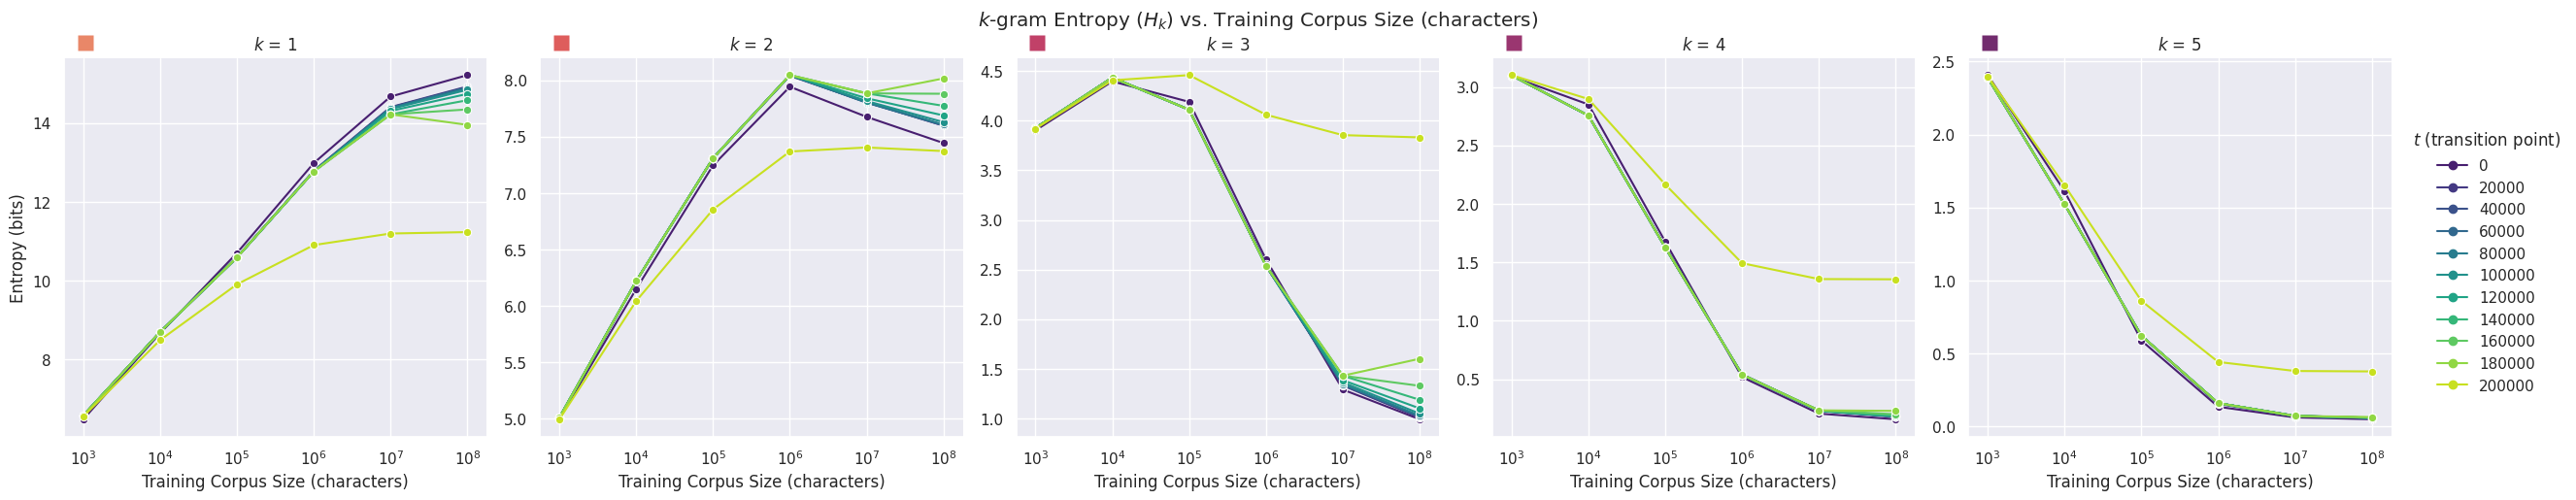

In [38]:
entropy_fig = sns.relplot(
    data=entropy_long,
    x="train_chars",
    y="entropy",
    hue="t",
    col="k",
    kind="line",
    marker="o",
    palette="viridis",
    facet_kws={"sharey": False},
)
entropy_fig.set(xscale="log")
entropy_fig.set_axis_labels("Training Corpus Size (characters)", "Entropy (bits)")
entropy_fig.set_titles(r"$k$ = {col_name}")
sns.move_legend(
    entropy_fig,
    "center left",
    bbox_to_anchor=(0.95, 0.5),
    title=r"$t$ (transition point)",
)
entropy_fig.figure.suptitle(
    "$k$-gram Entropy ($H_k$) vs. Training Corpus Size (characters)", y=1.02
)


# Add a colored square marker above each subplot using the flare color for that
# k value. Gives a shared visual key with the other figures without affecting
# title readability.
k_colors = dict(
    zip(
        sorted(entropy_long["k"].unique()),
        sns.color_palette("flare", n_colors=entropy_long["k"].nunique()),
    )
)
for ax, k_val in zip(entropy_fig.axes.flat, entropy_fig.col_names):
    ax.plot(
        0.05,
        1.04,
        marker="s",
        color=k_colors[k_val],
        markersize=12,
        markeredgecolor="none",
        transform=ax.transAxes,
        clip_on=False,
    )

### 4a (Different $t$ Per Subplot)

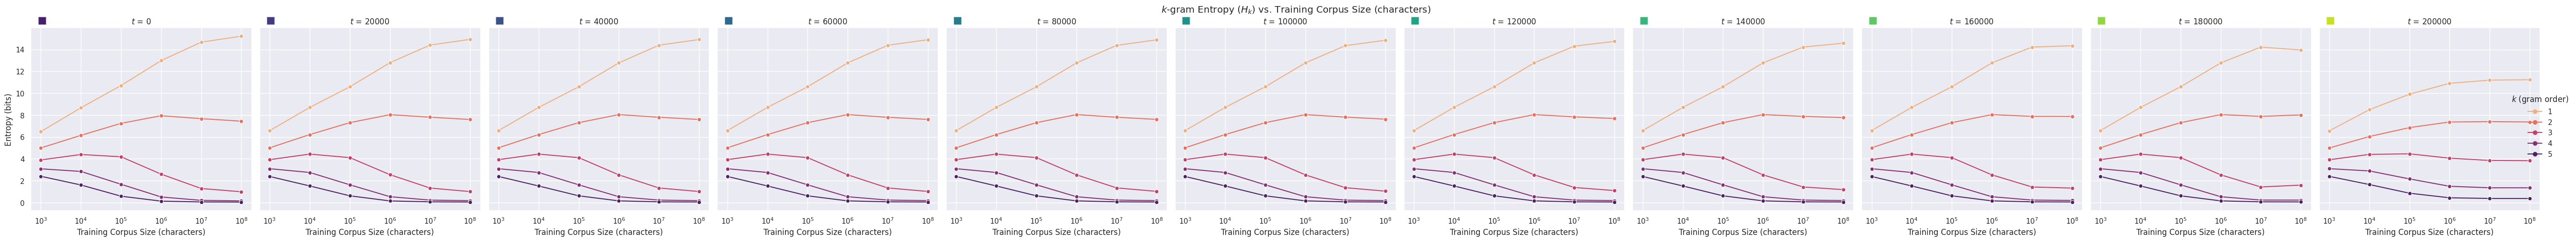

In [39]:
# Paper-style layout: one subplot per t, with H_1..H_5 as separate lines.
# k gets its own palette (mako) so it stays visually distinct from t (viridis,
# used everywhere else).
entropy_orig_fig = sns.relplot(
    data=entropy_long,
    x="train_chars",
    y="entropy",
    hue="k",
    col="t",
    kind="line",
    marker="o",
    palette="flare",
)
entropy_orig_fig.set(xscale="log")
entropy_orig_fig.set_axis_labels("Training Corpus Size (characters)", "Entropy (bits)")
entropy_orig_fig.set_titles("$t$ = {col_name}")
sns.move_legend(
    entropy_orig_fig,
    "center left",
    bbox_to_anchor=(0.965, 0.5),
    title=r"$k$ (gram order)",
)
entropy_orig_fig.figure.suptitle(
    "$k$-gram Entropy ($H_k$) vs. Training Corpus Size (characters)", y=1.02
)

# Add a colored square marker above each subplot using the viridis color for that
# t value. Gives a shared visual key with the other figures without affecting
# title readability.
t_colors = dict(
    zip(
        sorted(df["t"].unique()),
        sns.color_palette("viridis", n_colors=df["t"].nunique()),
    )
)
for ax, t_val in zip(entropy_orig_fig.axes.flat, entropy_orig_fig.col_names):
    ax.plot(
        0.05,
        1.04,
        marker="s",
        color=t_colors[t_val],
        markersize=12,
        markeredgecolor="none",
        transform=ax.transAxes,
        clip_on=False,
    )

### 4b Alternative (Different $k$ Per Subplot)

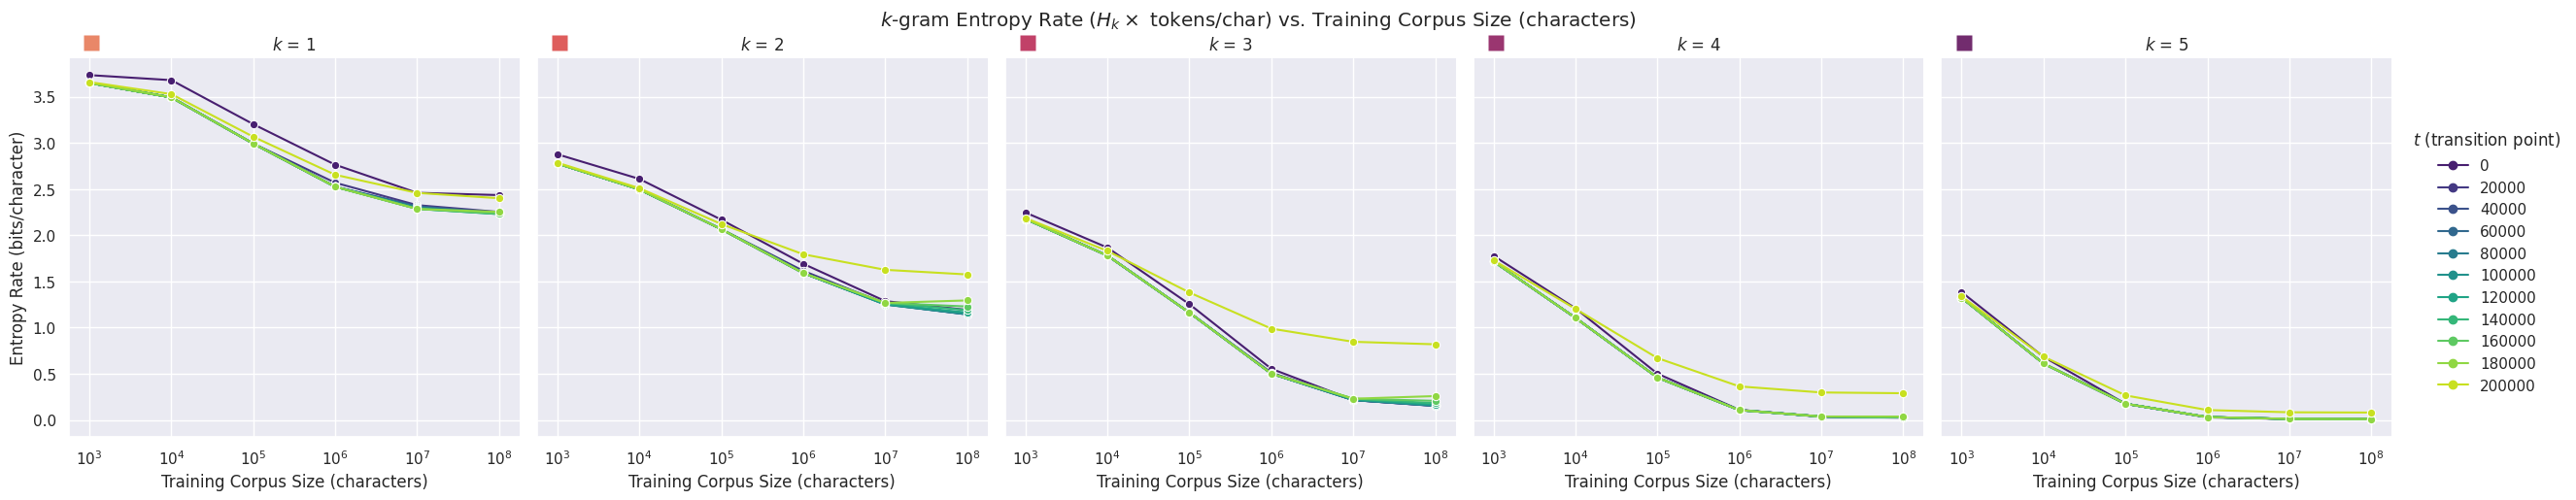

In [40]:
entropy_rate_fig = sns.relplot(
    data=entropy_rate_long,
    x="train_chars",
    y="entropy_rate",
    hue="t",
    col="k",
    kind="line",
    marker="o",
    palette="viridis",
)

entropy_rate_fig.set(xscale="log")
entropy_rate_fig.set_axis_labels(
    "Training Corpus Size (characters)", "Entropy Rate (bits/character)"
)
entropy_rate_fig.set_titles(r"$k$ = {col_name}")
sns.move_legend(
    entropy_rate_fig,
    "center left",
    bbox_to_anchor=(0.95, 0.5),
    title=r"$t$ (transition point)",
)
entropy_rate_fig.figure.suptitle(
    r"$k$-gram Entropy Rate ($H_k \times$ tokens/char) vs. Training Corpus Size (characters)",
    y=1.02,
)


# Add a colored square marker above each subplot using the flare color for that
# k value. Gives a shared visual key with the other figures without affecting
# title readability.
k_colors = dict(
    zip(
        sorted(entropy_rate_long["k"].unique()),
        sns.color_palette("flare", n_colors=entropy_rate_long["k"].nunique()),
    )
)
for ax, k_val in zip(entropy_rate_fig.axes.flat, entropy_rate_fig.col_names):
    ax.plot(
        0.05,
        1.04,
        marker="s",
        color=k_colors[k_val],
        markersize=12,
        markeredgecolor="none",
        transform=ax.transAxes,
        clip_on=False,
    )

### 4b (Different $t$ Per Subplot)

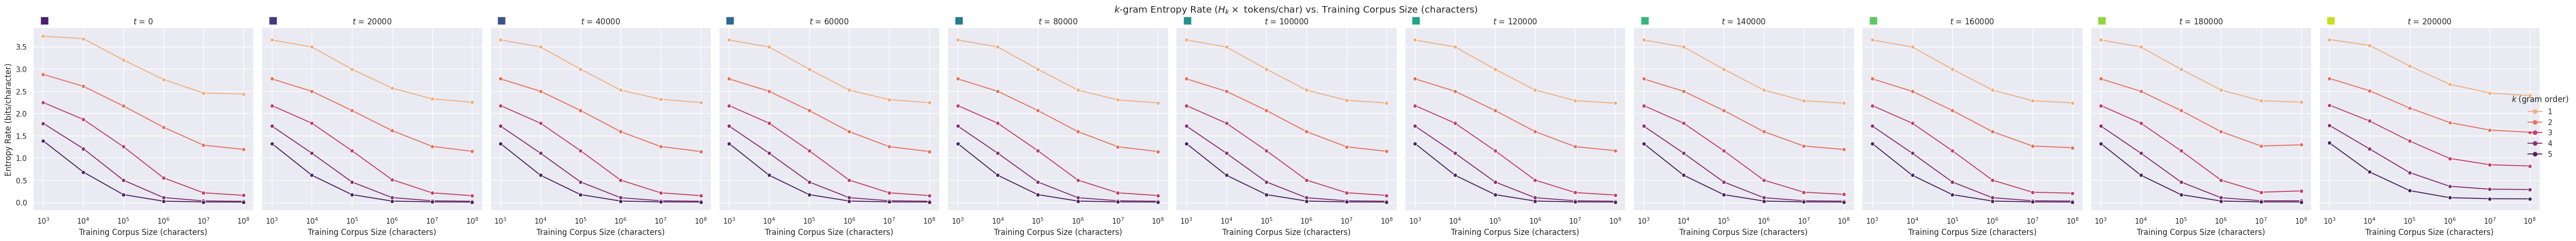

In [41]:
# Paper-style layout: one subplot per t, with H_1..H_5 entropy rates as separate lines.
entropy_rate_orig_fig = sns.relplot(
    data=entropy_rate_long,
    x="train_chars",
    y="entropy_rate",
    hue="k",
    col="t",
    kind="line",
    marker="o",
    palette="flare",
)
entropy_rate_orig_fig.set(xscale="log")
entropy_rate_orig_fig.set_axis_labels(
    "Training Corpus Size (characters)", "Entropy Rate (bits/character)"
)
entropy_rate_orig_fig.set_titles("$t$ = {col_name}")
sns.move_legend(
    entropy_rate_orig_fig,
    "center left",
    bbox_to_anchor=(0.965, 0.5),
    title=r"$k$ (gram order)",
)
entropy_rate_orig_fig.figure.suptitle(
    r"$k$-gram Entropy Rate ($H_k \times$ tokens/char) vs. Training Corpus Size (characters)",
    y=1.02,
)

# Add a colored square marker above each subplot using the viridis color for that
# t value. Gives a shared visual key with the other figures without affecting
# title readability.
t_colors = dict(
    zip(
        sorted(df["t"].unique()),
        sns.color_palette("viridis", n_colors=df["t"].nunique()),
    )
)
for ax, t_val in zip(entropy_rate_orig_fig.axes.flat, entropy_rate_orig_fig.col_names):
    ax.plot(
        0.05,
        1.04,
        marker="s",
        color=t_colors[t_val],
        markersize=12,
        markeredgecolor="none",
        transform=ax.transAxes,
        clip_on=False,
    )

## 4. Figure 8: Capacity Utilization vs Training Size

Reproduces Fig. 8 of Erdogan et al. (2026)

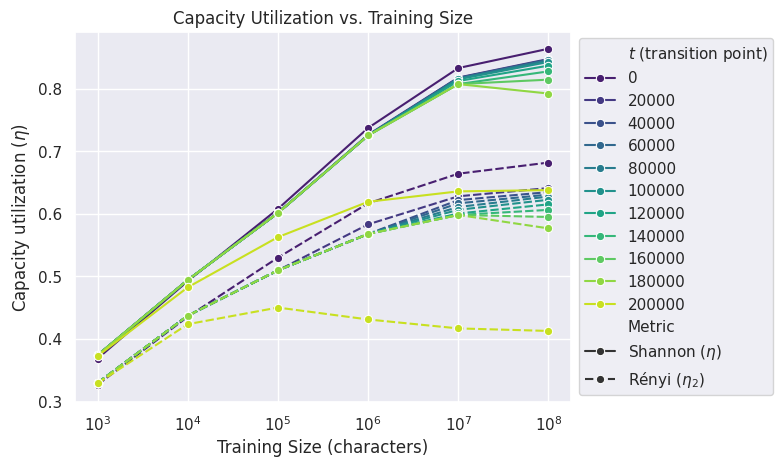

In [42]:
# Melt eta + eta_2 into long form so seaborn can map them to linestyle automatically.
util_long = df.melt(
    id_vars=["t", "train_chars"],
    value_vars=["eta", "eta_2"],
    var_name="metric",
    value_name="utilization",
)
util_long["metric"] = util_long["metric"].map(
    {"eta": r"Shannon ($\eta$)", "eta_2": r"Rényi ($\eta_2$)"}
)

capacity_utilization_fig = sns.lineplot(
    data=util_long,
    x="train_chars",
    y="utilization",
    hue="t",
    style="metric",
    marker="o",
    palette="viridis",
)
capacity_utilization_fig.set(
    xscale="log",
    xlabel="Training Size (characters)",
    ylabel=r"Capacity utilization ($\eta$)",
    title="Capacity Utilization vs. Training Size",
)

sns.move_legend(capacity_utilization_fig, "center left", bbox_to_anchor=(1, 0.5))
title_map = {"t": r"$t$ (transition point)", "metric": "Metric"}
for text in capacity_utilization_fig.get_legend().get_texts():
    if text.get_text() in title_map:
        text.set_text(title_map[text.get_text()])

## 5. Cross-Boundary Token Fraction vs Training Size

Counts the fraction of tokens in the test stream that cross the whitespace boundary (i.e, are SuperBPE-style tokens)

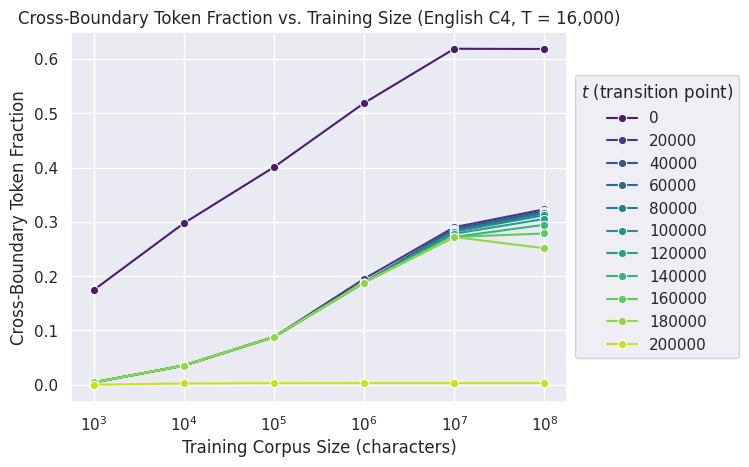

In [43]:
cbf_fig = sns.lineplot(
    data=df,
    x="train_chars",
    y="cross_boundary_frac",
    hue="t",
    marker="o",
    palette="viridis",
)

cbf_fig.set(
    xscale="log",
    xlabel="Training Corpus Size (characters)",
    ylabel="Cross-Boundary Token Fraction",
    title="Cross-Boundary Token Fraction vs. Training Size (English C4, T = 16,000)",
)
sns.move_legend(
    cbf_fig,
    "center left",
    bbox_to_anchor=(1, 0.5),
    title=r"$t$ (transition point)",
)